# Redes Convolucionales y Multi-Task Learning: Analítica de Audiencias en el *Edge*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/04_deep_learning/09_redes_convolucionales_cnn.ipynb)

## Objetivos


- Comprender la anatomía de una CNN (Filtros, *Pooling*, Campo Receptivo) y por qué superan a las Redes Densas en el procesamiento de imágenes.
- Diseñar una arquitectura **Multi-Cabeza** (API Funcional) para resolver simultáneamente un problema de Clasificación (Género) y Regresión (Edad).
- **Criterio de Ingeniería:** Dominar el preprocesamiento crítico para regresión visual (escalado del *target*) y evitar el colapso de la función de activación.
- Evaluar la viabilidad de despliegue en hardware embebido (latencia, tamaño del modelo) y discutir las implicaciones éticas (sesgos y privacidad por diseño).



## Prerrequisitos


- Dominio de la API Funcional de Keras y Callbacks.
- Haber completado: [El Ecosistema Keras y APIs](06_ecosistema_keras_y_apis.ipynb) y [Callbacks y KerasTuner](07_callbacks_y_kerastuner.ipynb).

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio, descarga los datos e importa utilidades*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

    # Descarga del dataset age_gender desde repositorio en Drive
    if not os.path.exists("age_gender.zip"):
        subprocess.run(["pip", "install", "-q", "gdown"], check=True)
        import gdown
        gdown.download(f"https://drive.google.com/uc?id=1kWUodrpx2nolRxwld9aa9kPLE6MbGFud", "age_gender.zip", quiet=False)
        subprocess.run(["unzip", "-qq", "age_gender.zip"], check=True)
else:
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, mean_absolute_error

keras.utils.set_random_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detectada: {gpus[0].name}")
else:
    print("ADVERTENCIA: No se detectó GPU. El entrenamiento será MUY lento.")


Downloading...
From (original): https://drive.google.com/uc?id=1kWUodrpx2nolRxwld9aa9kPLE6MbGFud
From (redirected): https://drive.google.com/uc?id=1kWUodrpx2nolRxwld9aa9kPLE6MbGFud&confirm=t&uuid=e755a74e-6b50-4678-a65d-901c0057fe48
To: /content/applied-ai-engineering/age_gender.zip
100%|██████████| 66.3M/66.3M [00:02<00:00, 29.2MB/s]


ADVERTENCIA: No se detectó GPU. El entrenamiento será lento.


> **NOTA**: ahora aparecen capas de Convolución 2D. La diferencia entre ejecutar con CPU y GPU es notable. Incluso en problemas con imágenes de juguete (pequeñas y de un canal de color, como las que usamos aquí).

## 1. El Problema de Negocio y la Teoría Convolucional


**El Contexto:** Una empresa de tecnología nos ha contratado para desarrollar un sistema de analítica de audiencias para centros comerciales. El sistema debe procesar *frames* de video de cámaras de seguridad, detectar rostros y estimar la **edad** y el **género** de las personas en tiempo real.
Por restricciones de privacidad (GDPR), el sistema no puede almacenar imágenes ni enviarlas a la nube; debe procesarlas localmente en hardware embebido (*Edge Computing*, ej. Raspberry Pi) y emitir solo datos tabulares agregados.

### La Teoría: ¿Por qué no usar un Perceptrón Multicapa (MLP)?


Si aplanamos una pequeña imagen en escala de grises de 48x48 píxeles, obtenemos un vector 1D de `2.304` entradas.
- **Explosión de Parámetros:** Si conectamos esto a una sola capa densa de 512 neuronas, esa capa tendrá `(2304 * 512) + 512 = 1.180.160` parámetros. Desde un inicio ya, difícil de correr eficientemente en hardware pequeño.
- **Pérdida de Topología:** Al aplanar la imagen, la red olvida que el píxel del ojo está arriba del píxel de la nariz. Pierde el contexto espacial 2D.

### La Solución: Redes Convolucionales (CNN)

Las CNNs resuelven esto usando **Filtros (*Kernels*)**, pequeñas matrices (ej. 3x3) que se deslizan por la imagen realizando multiplicaciones matemáticas (producto punto).

1. **La Convolución:** Un filtro de 3x3 busca un patrón específico (ej. un borde vertical). Al deslizarse por toda la imagen, genera un "Mapa de Características" (*Feature Map*) que se ilumina donde encuentra ese patrón. ¡Un filtro de 3x3 tiene solo 9 parámetros, sin importar el tamaño de la imagen!
2. **Strides (Pasos):** Es la cantidad de píxeles que el filtro salta al deslizarse. Un *stride* de 1 analiza cada píxel. Un *stride* de 2 salta de a dos, reduciendo el tamaño de la imagen resultante a la mitad.
3. **Padding (Relleno):** Al aplicar un filtro de 3x3, los bordes de la imagen original se pierden. Si usamos `padding='same'`, Keras añade un borde de ceros alrededor de la imagen para que el mapa de características resultante tenga el mismo tamaño que la entrada.
4. **Campo Receptivo (*Receptive Field*):** En la primera capa, un filtro de 3x3 solo "ve" 9 píxeles. Pero en la tercera capa, debido a la reducción de dimensionalidad, un filtro de 3x3 está "viendo" un área que corresponde a 20x20 píxeles de la imagen original. Así es como la red pasa de detectar líneas simples a detectar rostros completos.

A continuación, una animación rudimentaria de este proceso, tomando como base un *kernel* clásico para detección de bordes verticales:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# =========================================================
# MATRIZ DE ENTRADA (5x5)
# =========================================================
image = np.array([
    [10, 20, 30, 0, 0],
    [15, 25, 35, 0, 0],
    [20, 30, 40, 0, 0],
    [0,  0,  0,  0, 0],
    [0,  0,  0,  0, 0]
])

# =========================================================
# KERNEL 3x3
# Detector de bordes verticales
# =========================================================
kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

# =========================================================
# DIMENSIONES DEL FEATURE MAP
# =========================================================
out_h = image.shape[0] - kernel.shape[0] + 1
out_w = image.shape[1] - kernel.shape[1] + 1

feature_map = np.zeros((out_h, out_w))

# =========================================================
# FIGURA PRINCIPAL
# =========================================================
fig = plt.figure(figsize=(13, 5.8))

ax_input = plt.subplot2grid((2, 4), (0, 0))
ax_kernel = plt.subplot2grid((2, 4), (0, 1))
ax_mult = plt.subplot2grid((2, 4), (0, 2))
ax_output = plt.subplot2grid((2, 4), (0, 3))
ax_text = plt.subplot2grid((2, 4), (1, 0), colspan=4)

# =========================================================
# UTILIDAD PARA DIBUJAR MATRICES
# =========================================================
def draw_matrix(ax, matrix, title, cmap='Blues', highlight=None):
    ax.clear()

    ax.imshow(matrix, cmap=cmap)
    ax.set_title(title, fontsize=14, weight='bold')

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f'{matrix[i,j]:.0f}',
                    ha='center',
                    va='center',
                    fontsize=14,
                    color='black')

    ax.set_xticks([])
    ax.set_yticks([])

    if highlight:
        x, y, w, h = highlight
        rect = Rectangle((x - 0.5, y - 0.5),
                         w,
                         h,
                         linewidth=3,
                         edgecolor='red',
                         facecolor='none')
        ax.add_patch(rect)

# =========================================================
# PRECOMPUTAR TODOS LOS PASOS
# =========================================================
steps = []

for i in range(out_h):
    for j in range(out_w):

        region = image[i:i+3, j:j+3]
        mult = region * kernel
        result = np.sum(mult)

        steps.append({
            'i': i,
            'j': j,
            'region': region,
            'mult': mult,
            'result': result
        })

# =========================================================
# FUNCIÓN DE ANIMACIÓN
# =========================================================
def update(frame):

    step = steps[frame]

    i = step['i']
    j = step['j']

    region = step['region']
    mult = step['mult']
    result = step['result']

    feature_map[i, j] = result

    # -----------------------------------------------------
    # INPUT IMAGE
    # -----------------------------------------------------
    draw_matrix(
        ax_input,
        image,
        'Imagen de Entrada (5x5)',
        highlight=(j, i, 3, 3)
    )

    # -----------------------------------------------------
    # KERNEL
    # -----------------------------------------------------
    draw_matrix(
        ax_kernel,
        kernel,
        'Kernel (3x3)',
        cmap='Greens'
    )

    # -----------------------------------------------------
    # MULTIPLICACIÓN
    # -----------------------------------------------------
    draw_matrix(
        ax_mult,
        mult,
        'Producto Elemento a Elemento',
        cmap='Oranges'
    )

    # -----------------------------------------------------
    # FEATURE MAP
    # -----------------------------------------------------
    draw_matrix(
        ax_output,
        feature_map,
        'Feature Map',
        cmap='Purples'
    )

    # -----------------------------------------------------
    # TEXTO EXPLICATIVO
    # -----------------------------------------------------
    ax_text.clear()
    ax_text.axis('off')

    formula_lines = []

    for r in range(3):
        line = []
        for c in range(3):
            a = region[r, c]
            b = kernel[r, c]
            line.append(f'{a}×{b}')
        formula_lines.append(' + '.join(line))

    formula = '\n'.join(formula_lines)

    ax_text.text(
        0.02,
        0.75,
        f'Región activa: posición ({i}, {j})',
        fontsize=18,
        weight='bold'
    )

    ax_text.text(
        0.02,
        0.30,
        formula,
        fontsize=16,
        family='monospace'
    )

    ax_text.text(
        0.70,
        0.45,
        f'Suma = {result}',
        fontsize=24,
        color='darkred',
        weight='bold'
    )

    # Compactar márgenes internos
    plt.tight_layout(pad=1.2)

# =========================================================
# CREAR ANIMACIÓN
# =========================================================
anim = FuncAnimation(
    fig,
    update,
    frames=len(steps),
    interval=1500,
    repeat=True
)

# =========================================================
# MOSTRAR EN COLAB / JUPYTER
# =========================================================
fig.subplots_adjust(
    left=0.03,
    right=0.98,
    top=0.90,
    bottom=0.08,
    wspace=0.25,
    hspace=0.15
)

plt.close(fig) # Evita renderizar el del principio "suelto"
HTML(anim.to_jshtml())

<Figure size 1500x900 with 0 Axes>

Además, es común utilizar capas de *Pooling* junto a las convolucionales. De modo de reducir la dimensionalidad espacial del *feature map*, conservando las activaciones más importantes de cada región local. Además de eso, este proceso típicamente aporta:
- reducción del costo computacional
- mejorar robustez ante pequeñas traslaciones
- permitir que las CNN extraigan características más compactas y semánticas.


A continuación, un pequeño ejemplo con la operación `MaxPooling`; que identifica el valor máximo y simplemente lo copia al mapa de salida.

In [20]:
# =========================================================
# FEATURE MAP DE ENTRADA
# =========================================================

feature_map = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [2, 0, 3, 1],
    [4, 2, 1, 0]
])

# =========================================================
# CONFIGURACIÓN MAXPOOLING
# =========================================================

pool_size = 2
stride = 2

out_h = feature_map.shape[0] // 2
out_w = feature_map.shape[1] // 2

pooled_map = np.zeros((out_h, out_w))


fig = plt.figure(figsize=(13, 5.8))

ax_input = plt.subplot2grid((2, 4), (0, 0))
ax_window = plt.subplot2grid((2, 4), (0, 1))
ax_output = plt.subplot2grid((2, 4), (0, 2))
ax_progress = plt.subplot2grid((2, 4), (0, 3))
ax_text = plt.subplot2grid((2, 4), (1, 0), colspan=4)

# =========================================================
# UTILIDAD PARA MATRICES
# =========================================================

def draw_matrix(
    ax,
    matrix,
    title,
    cmap='Blues',
    highlight=None,
    highlight_cell=None
):

    ax.clear()

    ax.imshow(matrix, cmap=cmap)

    ax.set_title(
        title,
        fontsize=14,
        weight='bold'
    )

    # -----------------------------------------------------
    # TEXTO DE CELDAS
    # -----------------------------------------------------

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):

            color = 'black'
            weight = 'normal'

            if highlight_cell == (i, j):
                color = 'darkred'
                weight = 'bold'

            ax.text(
                j,
                i,
                f'{matrix[i,j]:.0f}',
                ha='center',
                va='center',
                fontsize=15,
                color=color,
                weight=weight
            )

    ax.set_xticks([])
    ax.set_yticks([])

    # -----------------------------------------------------
    # RECTÁNGULO
    # -----------------------------------------------------

    if highlight:

        x, y, w, h = highlight

        rect = Rectangle(
            (x - 0.5, y - 0.5),
            w,
            h,
            linewidth=3,
            edgecolor='red',
            linestyle='--',
            facecolor='none'
        )

        ax.add_patch(rect)

# =========================================================
# PRECOMPUTAR PASOS
# =========================================================

steps = []

for i in range(0, feature_map.shape[0], stride):
    for j in range(0, feature_map.shape[1], stride):

        window = feature_map[i:i+2, j:j+2]

        max_value = np.max(window)

        local_pos = np.unravel_index(
            np.argmax(window),
            window.shape
        )

        global_pos = (
            i + local_pos[0],
            j + local_pos[1]
        )

        out_i = i // stride
        out_j = j // stride

        steps.append({
            'i': i,
            'j': j,
            'window': window,
            'max_value': max_value,
            'global_pos': global_pos,
            'out_i': out_i,
            'out_j': out_j
        })

# =========================================================
# ANIMACIÓN
# =========================================================

def update(frame):

    step = steps[frame]

    i = step['i']
    j = step['j']

    window = step['window']

    max_value = step['max_value']

    global_pos = step['global_pos']

    out_i = step['out_i']
    out_j = step['out_j']

    pooled_map[out_i, out_j] = max_value

    # =====================================================
    # INPUT FEATURE MAP
    # =====================================================

    draw_matrix(
        ax_input,
        feature_map,
        '1. Feature Map',
        cmap='Blues',
        highlight=(j, i, 2, 2),
        highlight_cell=global_pos
    )

    # =====================================================
    # VENTANA ACTUAL
    # =====================================================

    local_max = np.unravel_index(
        np.argmax(window),
        window.shape
    )

    draw_matrix(
        ax_window,
        window,
        '2. Ventana 2×2',
        cmap='Greens',
        highlight_cell=local_max
    )

    # =====================================================
    # OUTPUT POOLED MAP
    # =====================================================

    draw_matrix(
        ax_output,
        pooled_map,
        '3. Pooled Map',
        cmap='Purples',
        highlight=(out_j, out_i, 1, 1)
    )

    # =====================================================
    # PROGRESO
    # =====================================================

    ax_progress.clear()

    progress = (frame + 1) / len(steps)

    ax_progress.barh(
        [0],
        [progress]
    )

    ax_progress.set_xlim(0, 1)

    ax_progress.set_title(
        '4. Progreso',
        fontsize=14,
        weight='bold'
    )

    ax_progress.set_yticks([])

    ax_progress.set_xticks([])

    ax_progress.text(
        0.5,
        0,
        f'{int(progress*100)}%',
        ha='center',
        va='center',
        fontsize=16,
        weight='bold'
    )

    # =====================================================
    # TEXTO EXPLICATIVO
    # =====================================================

    ax_text.clear()

    ax_text.axis('off')

    explanation = f"""
Ventana actual:

{window}

Máximo seleccionado = {max_value}

Posición original:
fila={global_pos[0]}, columna={global_pos[1]}

El valor máximo se conserva y se copia al mapa de salida.
"""

    ax_text.text(
        0.02,
        -0.2,
        explanation,
        fontsize=15,
        family='monospace'
    )

    plt.tight_layout(pad=1.2)

# =========================================================
# CREAR ANIMACIÓN
# =========================================================

anim = FuncAnimation(
    fig,
    update,
    frames=len(steps),
    interval=1600,
    repeat=True
)

fig.subplots_adjust(
    left=0.03,
    right=0.98,
    top=0.90,
    bottom=0.08,
    wspace=0.25,
    hspace=0.15
)

plt.close(fig)
HTML(anim.to_jshtml())

<Figure size 1500x900 with 0 Axes>

## 2. Comprensión y Preprocesamiento de Datos


Cargamos el dataset y transformamos los píxeles (que vienen en formato de texto) a tensores matemáticos 2D.

Total de imágenes: 23705


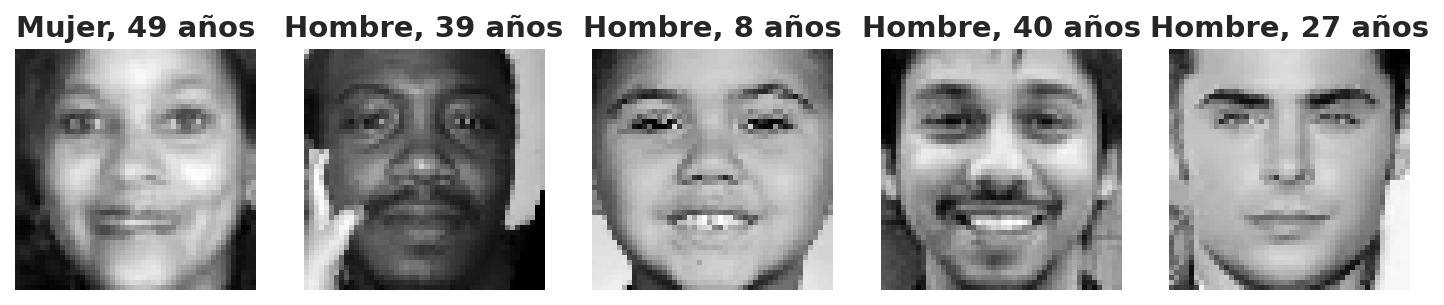

In [6]:
# 1. Carga de datos
dataset = pd.read_csv("age_gender.csv")
# Mezclamos el dataset para evitar sesgos de orden
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total de imágenes: {len(dataset)}")

# 2. Transformación Espacial (De String a Tensor 2D)
# Convertimos la cadena de texto separada por espacios a un array de numpy de 48x48x1
X = np.array([np.array(x.split(), dtype='float32').reshape(48, 48, 1) for x in dataset['pixels']])

# Normalizamos los píxeles al rango [0, 1]
X = X / 255.0

# 3. Extracción de Targets
y_gender = dataset['gender'].values # 0: Hombre, 1: Mujer
y_age = dataset['age'].values

# Visualización de muestra
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X[i].reshape(48, 48), cmap='gray')
    genero_str = "Mujer" if y_gender[i] == 1 else "Hombre"
    plt.title(f"{genero_str}, {y_age[i]} años")
    plt.axis('off')
plt.show()

### El Truco de Ingeniería: Escalado del Target (Regresión)



Predecir el género es fácil (0 o 1). Pero predecir la edad implica que la red debe escupir un número entre 1 y 116.

> **⚠️ ALERTA DE INGENIERÍA (El Colapso de la Activación):**
> Si usamos una capa de salida `Dense(1, activation='linear')` para predecir edades absolutas, los errores iniciales serán gigantescos (ej. predecir 1 año cuando la persona tiene 80). Esto genera gradientes masivos que desestabilizan el optimizador Adam, haciendo que la pérdida (*Loss*) rebote en miles o colapse prediciendo siempre la edad media del dataset.

**La Solución:** Escalar la edad al rango `[0, 1]` usando `MinMaxScaler`. Esto nos permite usar una activación `sigmoid` en la capa de salida, acotando matemáticamente las predicciones y estabilizando el entrenamiento.



In [7]:
# Escalado de la Edad
scaler_age = MinMaxScaler()
y_age_scaled = scaler_age.fit_transform(y_age.reshape(-1, 1)).flatten()

# División en Train, Val y Test
X_temp, X_test, y_gender_temp, y_gender_test, y_age_temp, y_age_test = train_test_split(
    X, y_gender, y_age_scaled, test_size=0.15, random_state=42
)

X_train, X_val, y_gender_train, y_gender_val, y_age_train, y_age_val = train_test_split(
    X_temp, y_gender_temp, y_age_temp, test_size=0.15, random_state=42
)

print(f"Set de Entrenamiento: {len(X_train)} imágenes")

Set de Entrenamiento: 17126 imágenes


## 3. Arquitectura Multi-Cabeza (API Funcional)


Construimos un modelo **Multi-Task Learning**. En lugar de tener dos redes separadas (una para edad y otra para género), tendremos una "Base Compartida" que extrae características faciales, y dos "Cabezas" especializadas.
Esto reduce el tamaño del modelo a la mitad y acelera la inferencia, cumpliendo con nuestras restricciones de hardware embebido.

Además, sirve de ejemplo aplicado para sacarle el jugo a la API Funcional de Keras...

In [10]:
# --- 1. ENTRADA ---
inputs = keras.Input(shape=(48, 48, 1), name="imagen_entrada")

# --- 2. BASE COMPARTIDA (Feature Extractor) ---
# Bloque 1
x = keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.MaxPooling2D((2, 2))(x) # Reduce la imagen a 24x24

# Bloque 2
x = keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.MaxPooling2D((2, 2))(x) # Reduce la imagen a 12x12

# Bloque 3
x = keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.MaxPooling2D((2, 2))(x) # Reduce la imagen a 6x6

# --- 3. EL CUELLO DE BOTELLA MODERNO ---
# En lugar de Flatten() (que generaría 6*6*128 = 4608 parámetros por conexión),
# usamos GlobalAveragePooling2D. Promedia cada mapa de características de 6x6 en un solo número.
# Resultado: Un vector denso de exactamente 128 dimensiones. Altamente resistente al overfitting.
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.4)(x)

# --- 4. LAS CABEZAS (Bifurcación) ---
# Cabeza 1: Género (Clasificación Binaria)
head_gender = keras.layers.Dense(64, activation='relu')(x)
out_gender = keras.layers.Dense(1, activation='sigmoid', name='salida_genero')(head_gender)

# Cabeza 2: Edad (Regresión Acotada)
head_age = keras.layers.Dense(64, activation='relu')(x)
# Usamos Sigmoid porque escalamos la edad entre 0 y 1
out_age = keras.layers.Dense(1, activation='sigmoid', name='salida_edad')(head_age)

# --- 5. ENSAMBLAJE ---
modelo_multitask = keras.Model(inputs=inputs, outputs=[out_gender, out_age], name="CNN_Audiencias")
modelo_multitask.summary()

Model: "CNN_Audiencias"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ imagen_entrada      │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 48,    │        320 │ imagen_entrada[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 24, 24,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 12, 12,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 12, 12,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 12,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 6, 6, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_5[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ salida_genero       │ (None, 1)         │         65 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ salida_edad (Dense) │ (None, 1)         │         65 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 110,210 (430.51 KB)

 Trainable params: 109,762 (428.76 KB)

 Non-trainable params: 448 (1.75 KB)

### Aumento de Datos: Extra para el futuro

Hay muchas maneras de aumentar datos al tratar con imágenes, pero traigo a colación una incorporación de Keras 3.
Permite incorporar el proceso de aumento directamente como parte de la arquitectura del modelo. Lo dejo con un adelanto, en otro notebook lo cubrimos como corresponde...

> **NOTA**: probar de entrenar con el modelo de arriba (sin aumento) y con este (con aumento). ¿Se producen cambios?

In [22]:
# Bandera para evitar ejecución automática de este caso siempre
red_con_aumento = False

if (red_con_aumento):
    # --- 1. ENTRADA Y DATA AUGMENTATION ---
    inputs = keras.Input(shape=(48, 48, 1), name="imagen_entrada")

    # CRITERIO DE INGENIERÍA: Data Augmentation
    # En lugar de usar el antiguo ImageDataGenerator, Keras 3 permite integrar
    # el aumento de datos directamente en el grafo del modelo. Estas capas SOLO
    # se activan durante el entrenamiento (no en inferencia).
    # Nota: Para rostros, NO usamos rotaciones extremas ni volteo vertical (nadie camina de cabeza).
    data_augmentation = keras.Sequential([
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.05), # Rotación leve (±5%)
        keras.layers.RandomZoom(0.1)       # Zoom leve (±10%)
    ], name="data_augmentation")

    x = data_augmentation(inputs)

    # ----------------------------------------------
    #         Lo mismo de acá para abajo...
    # ----------------------------------------------
    # --- 2. BASE COMPARTIDA (Feature Extractor) ---
    # Bloque 1
    x = keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling2D((2, 2))(x) # Reduce a 24x24

    # Bloque 2
    x = keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling2D((2, 2))(x) # Reduce a 12x12

    # Bloque 3
    x = keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling2D((2, 2))(x) # Reduce a 6x6

    # --- 3. EL CUELLO DE BOTELLA MODERNO ---
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.4)(x)

    # --- 4. LAS CABEZAS (Bifurcación) ---
    # Cabeza 1: Género (Clasificación Binaria)
    head_gender = keras.layers.Dense(64, activation='relu')(x)
    out_gender = keras.layers.Dense(1, activation='sigmoid', name='salida_genero')(head_gender)

    # Cabeza 2: Edad (Regresión Acotada)
    head_age = keras.layers.Dense(64, activation='relu')(x)
    out_age = keras.layers.Dense(1, activation='sigmoid', name='salida_edad')(head_age)

    # --- 5. ENSAMBLAJE ---
    modelo_multitask = keras.Model(inputs=inputs, outputs=[out_gender, out_age], name="CNN_Audiencias")
    modelo_multitask.summary()
    print("Modelo Multitask CON CAPA DE DATA AUGMENTATION")

## 4. Compilación y Entrenamiento (Balanceo de Pérdidas)


Notar que cada salida tiene su pérdida y métrica:


In [11]:
# Con CPU demora 30 min. aprox.

# Compilación con diccionarios para asignar funciones específicas a cada cabeza
modelo_multitask.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'salida_genero': 'binary_crossentropy',
        'salida_edad': 'mse' # Usamos MSE para penalizar errores grandes en la edad
    },
    metrics={
        'salida_genero': ['accuracy'],
        'salida_edad': ['mae']
    }
)

# Callbacks, los de siempre
callbacks =[
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

print("Iniciando entrenamiento Multi-Task...")
historia = modelo_multitask.fit(
    X_train,
    {'salida_genero': y_gender_train, 'salida_edad': y_age_train},
    validation_data=(X_val, {'salida_genero': y_gender_val, 'salida_edad': y_age_val}),
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)
print("Entrenamiento finalizado.")

Iniciando entrenamiento Multi-Task...
Epoch 1/40
268/268 ━━━━━━━━━━━━━━━━━━━━ 69s 249ms/step - loss: 0.5725 - salida_edad_loss: 0.0272 - salida_edad_mae: 0.1278 - salida_genero_accuracy: 0.7245 - salida_genero_loss: 0.5449 - val_loss: 0.9677 - val_salida_edad_loss: 0.0314 - val_salida_edad_mae: 0.1478 - val_salida_genero_accuracy: 0.5435 - val_salida_genero_loss: 0.9336 - learning_rate: 0.0010
Epoch 2/40
268/268 ━━━━━━━━━━━━━━━━━━━━ 64s 238ms/step - loss: 0.4093 - salida_edad_loss: 0.0209 - salida_edad_mae: 0.1123 - salida_genero_accuracy: 0.8259 - salida_genero_loss: 0.3881 - val_loss: 0.4499 - val_salida_edad_loss: 0.0212 - val_salida_edad_mae: 0.1161 - val_salida_genero_accuracy: 0.7876 - val_salida_genero_loss: 0.4259 - learning_rate: 0.0010
Epoch 3/40
268/268 ━━━━━━━━━━━━━━━━━━━━ 64s 239ms/step - loss: 0.3483 - salida_edad_loss: 0.0181 - salida_edad_mae: 0.1042 - salida_genero_accuracy: 0.8524 - salida_genero_loss: 0.3300 - val_loss: 0.4223 - val_salida_edad_loss: 0.0185 - val_sal

¿Cómo optimiza la red si tiene dos objetivos distintos? Keras calcula la pérdida de cada cabeza y las suma.

> **⚠️ EL PROBLEMA DE LAS ESCALAS (`loss_weights`):**  
> La pérdida de Género (`binary_crossentropy`) suele rondar valores de `0.3` a `0.6`. La pérdida de Edad (`mse` sobre valores escalados) puede ser muy pequeña, ej. `0.01`. Si simplemente las sumamos, el optimizador prestará mucha más atención a mejorar el Género e ignorará la Edad.
> Para solucionar esto, podríamos usar `loss_weights` para multiplicar la pérdida de la Edad por un factor mayor, equilibrando la importancia de ambas tareas.

Ejemplo de cómo sería esto:

In [ ]:
# Bandera para evitar ejecución automática de este caso siempre
red_con_loss_weights = False

if (red_con_loss_weights):
    # Compilación con diccionarios y ponderación de pérdidas
    modelo_multitask.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss={
            'salida_genero': 'binary_crossentropy',
            'salida_edad': 'mse'
        },
        loss_weights={
            'salida_genero': 1.0,
            'salida_edad': 5.0  # Multiplicamos el MSE por 5 para darle más peso al gradiente
        },
        metrics={
            'salida_genero': ['accuracy'],
            'salida_edad': ['mae']
        }
    )

## 5. Evaluación y Diagnóstico de Tareas Múltiples



Vamos a evaluar el modelo en el Test Set (datos nunca vistos) y a invertir el escalado de la edad para interpretar el error en "años reales".



--- Reporte de Género (Clasificación) ---
              precision    recall  f1-score   support

      Hombre       0.90      0.89      0.89      1864
       Mujer       0.88      0.89      0.88      1692

    accuracy                           0.89      3556
   macro avg       0.89      0.89      0.89      3556
weighted avg       0.89      0.89      0.89      3556

--- Reporte de Edad (Regresión) ---
Error Absoluto Medio (MAE): 10.02 años


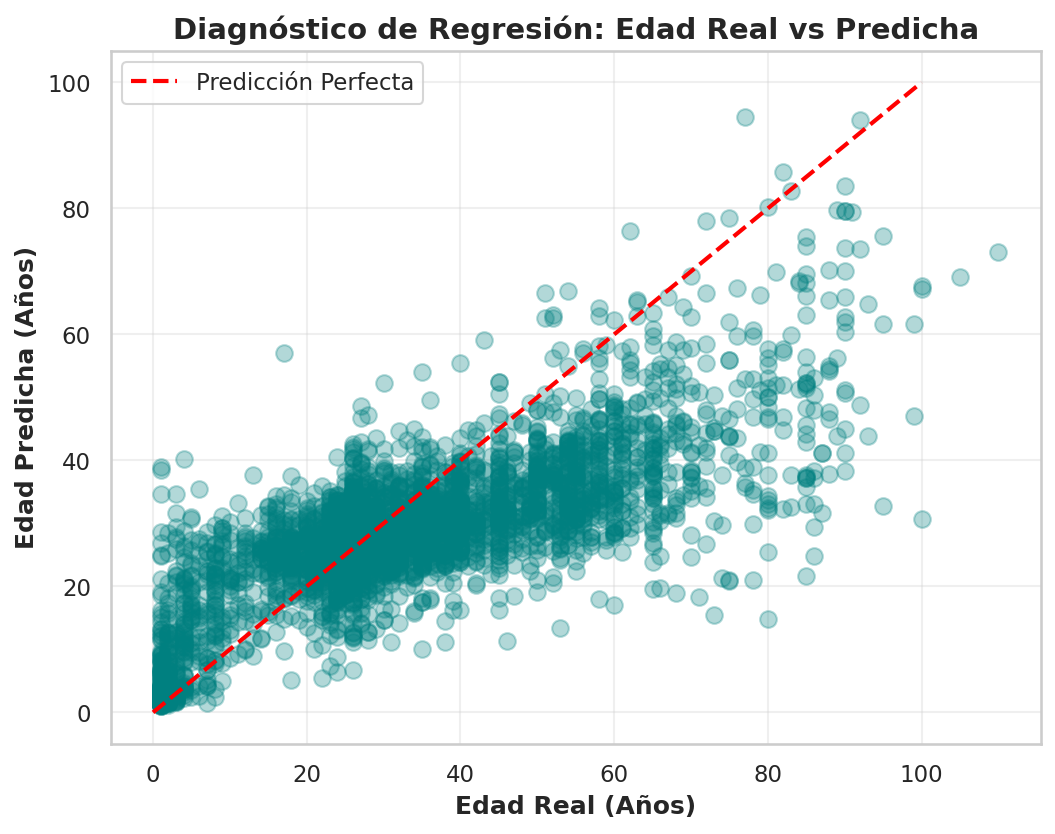

In [12]:
# 1. Predicción
pred_gender_probs, pred_age_scaled = modelo_multitask.predict(X_test, verbose=0)

# 2. Post-procesamiento
pred_gender_clases = (pred_gender_probs > 0.5).astype(int).flatten()
# Invertimos el escalado para volver a "Años de edad"
pred_age_real = scaler_age.inverse_transform(pred_age_scaled).flatten()
y_age_test_real = scaler_age.inverse_transform(y_age_test.reshape(-1, 1)).flatten()

# 3. Métricas
print("--- Reporte de Género (Clasificación) ---")
print(classification_report(y_gender_test, pred_gender_clases, target_names=['Hombre', 'Mujer']))

mae_edad = mean_absolute_error(y_age_test_real, pred_age_real)
print(f"--- Reporte de Edad (Regresión) ---")
print(f"Error Absoluto Medio (MAE): {mae_edad:.2f} años")

# 4. Diagnóstico Visual de la Regresión
plt.figure(figsize=(8, 6))
plt.scatter(y_age_test_real, pred_age_real, alpha=0.3, color='teal')
plt.plot([0, 100], [0, 100], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')
plt.title("Diagnóstico de Regresión: Edad Real vs Predicha")
plt.xlabel("Edad Real (Años)")
plt.ylabel("Edad Predicha (Años)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Análisis Comparativo de Dificultad


¿Por qué el modelo alcanza rápidamente un `~90%` de precisión en Género, pero tiene un error de `~10` años en Edad?
- **El Género** es un problema de clasificación binaria que depende de características morfológicas globales (mandíbula, cejas, cabello) que la CNN captura fácilmente.
- **La Edad** es un problema continuo y altamente ambiguo. La iluminación, el maquillaje, la genética y la calidad de la imagen (48x48 es muy baja resolución) hacen que incluso un humano se equivoque por 5 o 10 años al adivinar la edad de un extraño.

## 6. Abriendo la Caja Negra: Visualización de Filtros y Mapas

Una de las formas más pedagógicas de entender una CNN es ver exactamente qué está aprendiendo. Vamos a extraer la primera capa convolucional de nuestro modelo entrenado.

### A. Los Filtros Aprendidos

La primera capa tiene 32 filtros de 3x3. Estos filtros son los "ojos" de la red.


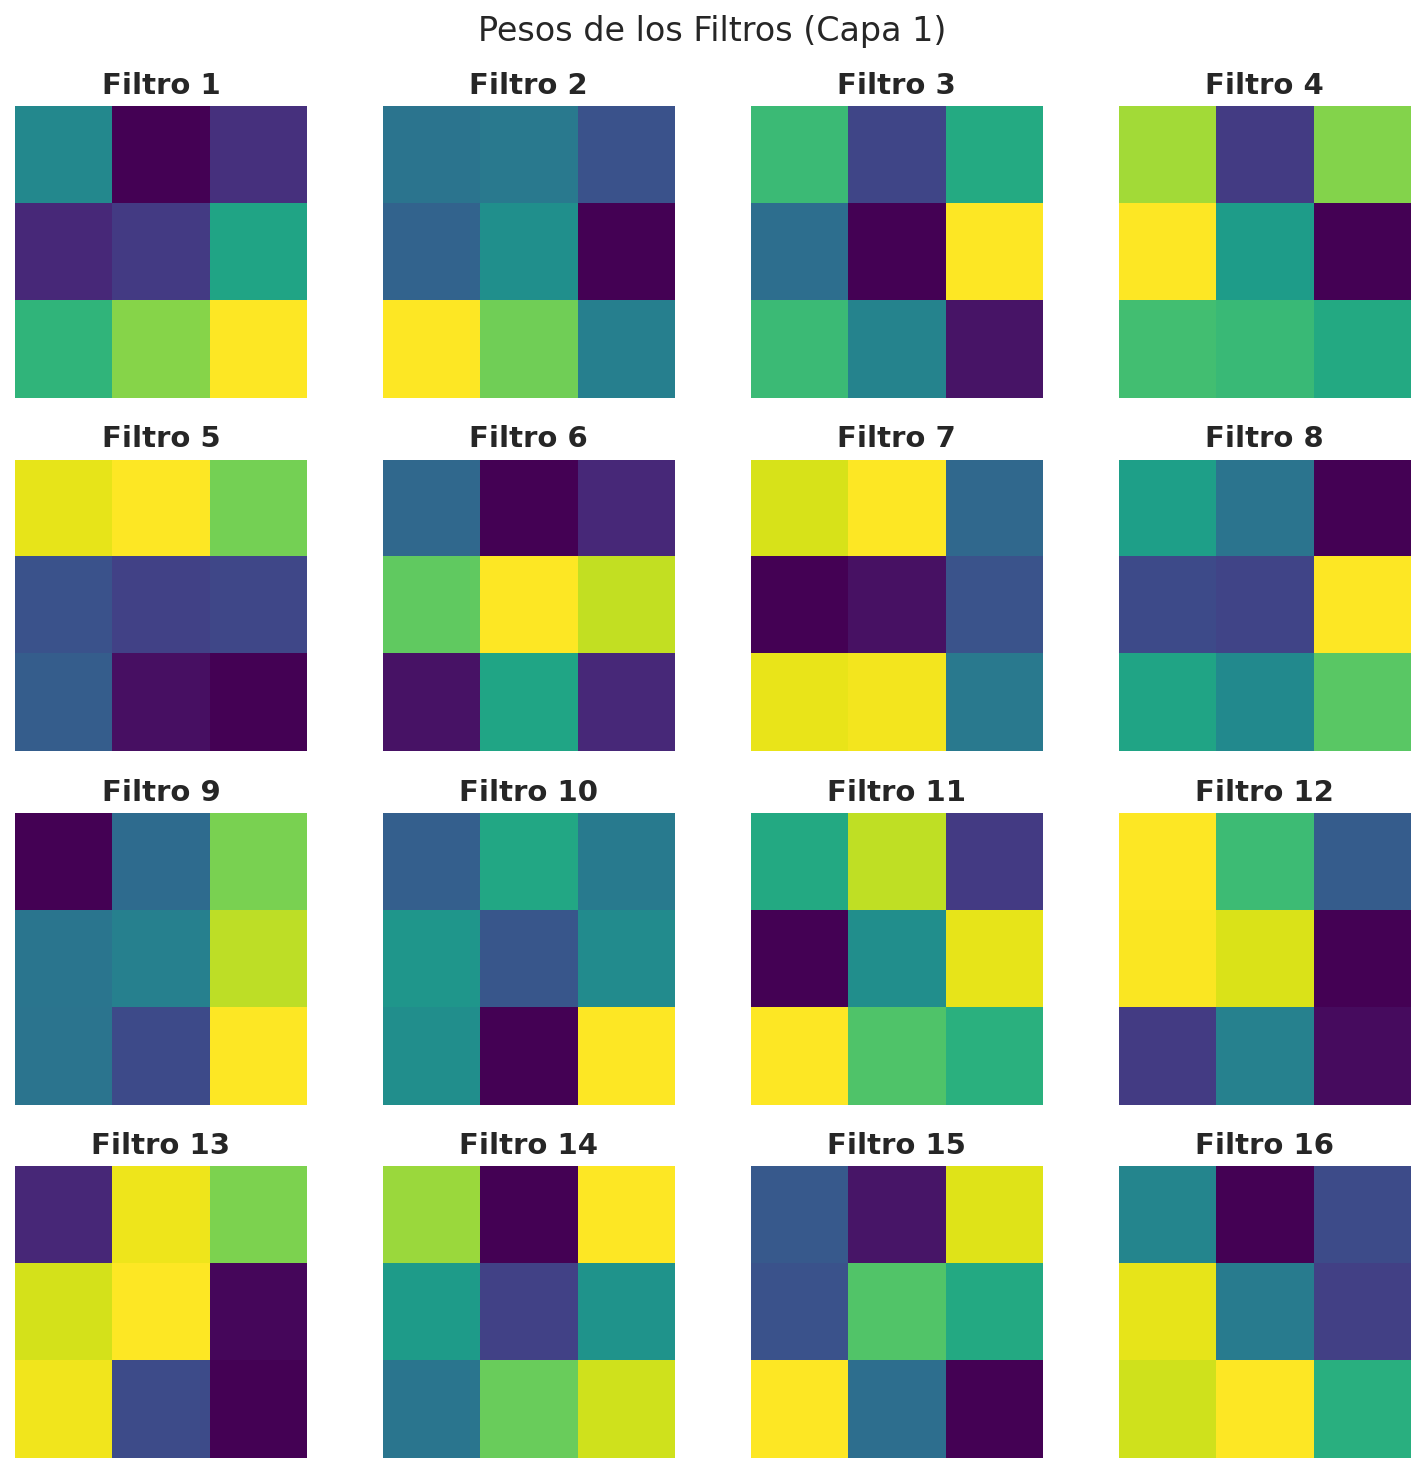

In [27]:
# Extraemos los pesos de la primera capa Conv2D
capa_conv1 = modelo_multitask.layers[1]
pesos_filtros, sesgos = capa_conv1.get_weights()

# Visualizamos los primeros 16 filtros
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    # Los pesos tienen forma (3, 3, canales_entrada, num_filtros)
    filtro = pesos_filtros[:, :, 0, i]
    plt.imshow(filtro, cmap='viridis')
    plt.axis('off')
    plt.title(f"Filtro {i+1}")
plt.suptitle("Pesos de los Filtros (Capa 1)", fontsize=16)
plt.tight_layout()
plt.show()

> **Nota**: Se ven patrones de colores claros y oscuros. Estos representan detectores de bordes diagonales, horizontales y verticales. No son los clásicos, la red "aprendió" los tipos de filtros que necesita para llevar adelante esta tarea.

En *pipelines* clásicos de visión por computadora, es necesario **definir manualmente** qué tipo de filtros se aplican. Aquí, se "deducen" en base a los datos.

## B. Los Mapas de Características (*Feature Maps*)

¿Qué pasa cuando pasamos un rostro por estos filtros? Vamos a crear un "sub-modelo" que se detenga en la primera capa para ver la salida.

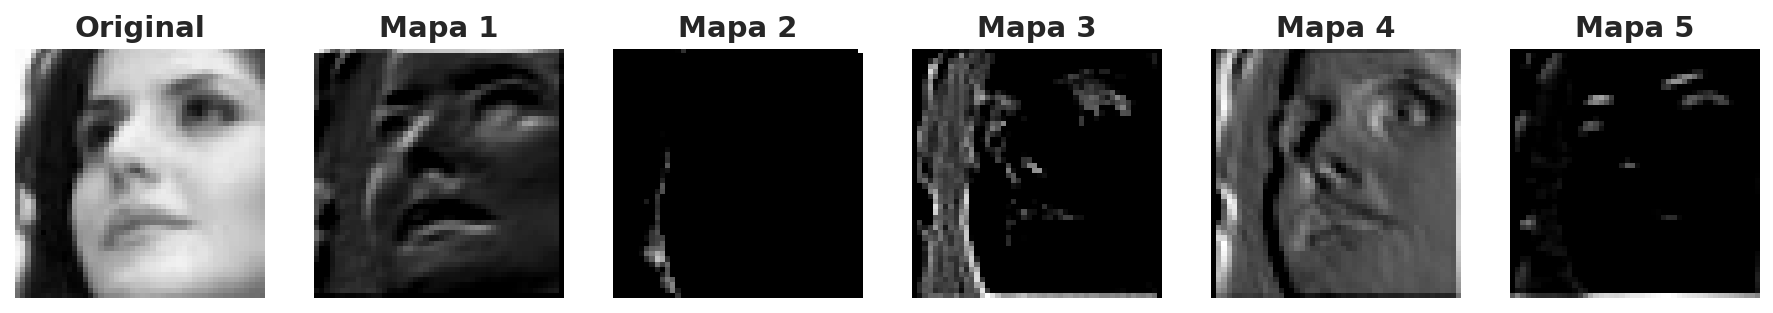

In [29]:
# Creamos un modelo que escupe la salida de la primera capa convolucional
extractor_mapas = keras.Model(inputs=modelo_multitask.inputs, outputs=capa_conv1.output)

# Tomamos una imagen de prueba
imagen_prueba = X_test[0:1] # Forma (1, 48, 48, 1)
mapas_activacion = extractor_mapas.predict(imagen_prueba, verbose=0)

# Visualizamos la imagen original y cómo la ven los primeros 5 filtros
plt.figure(figsize=(15, 3))
plt.subplot(1, 6, 1)
plt.imshow(imagen_prueba[0].reshape(48, 48), cmap='gray')
plt.title("Original")
plt.axis('off')

for i in range(5):
    plt.subplot(1, 6, i+2)
    plt.imshow(mapas_activacion[0, :, :, i], cmap='gray')
    plt.title(f"Mapa {i+1}")
    plt.axis('off')
plt.show()

**Lectura de Ingeniería**: Observar los mapas de características. Algunos filtros resaltan el contorno del rostro (bordes), otros iluminan los ojos, la boca, el cabello, incluso cuestiones que para nosotros pareciera que no tienen sentido. La red ha aprendido a descomponer la imagen en sus características fundamentales sin que nadie le haya enseñado explícitamente qué es un ojo o una nariz.

## 7. Poniendo el Modelo en Producción: *Pipeline* de Inferencia

Entrenar el modelo es solo la mitad del trabajo. En el mundo real, el modelo vivirá en un servidor o dispositivo *Edge* y recibirá archivos de imagen crudos (ej. `.jpg` o `.png`).

Debemos construir una función robusta que tome ese archivo, aplique **exactamente el mismo preprocesamiento** que usamos durante el entrenamiento, y traduzca las salidas matemáticas de la red a información legible para el negocio.


/tmp/ipykernel_7667/1782482379.py:71: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(imagen_test_cruda, mode='L').save(ruta_prueba)


--- Ejecutando Pipeline de Inferencia ---


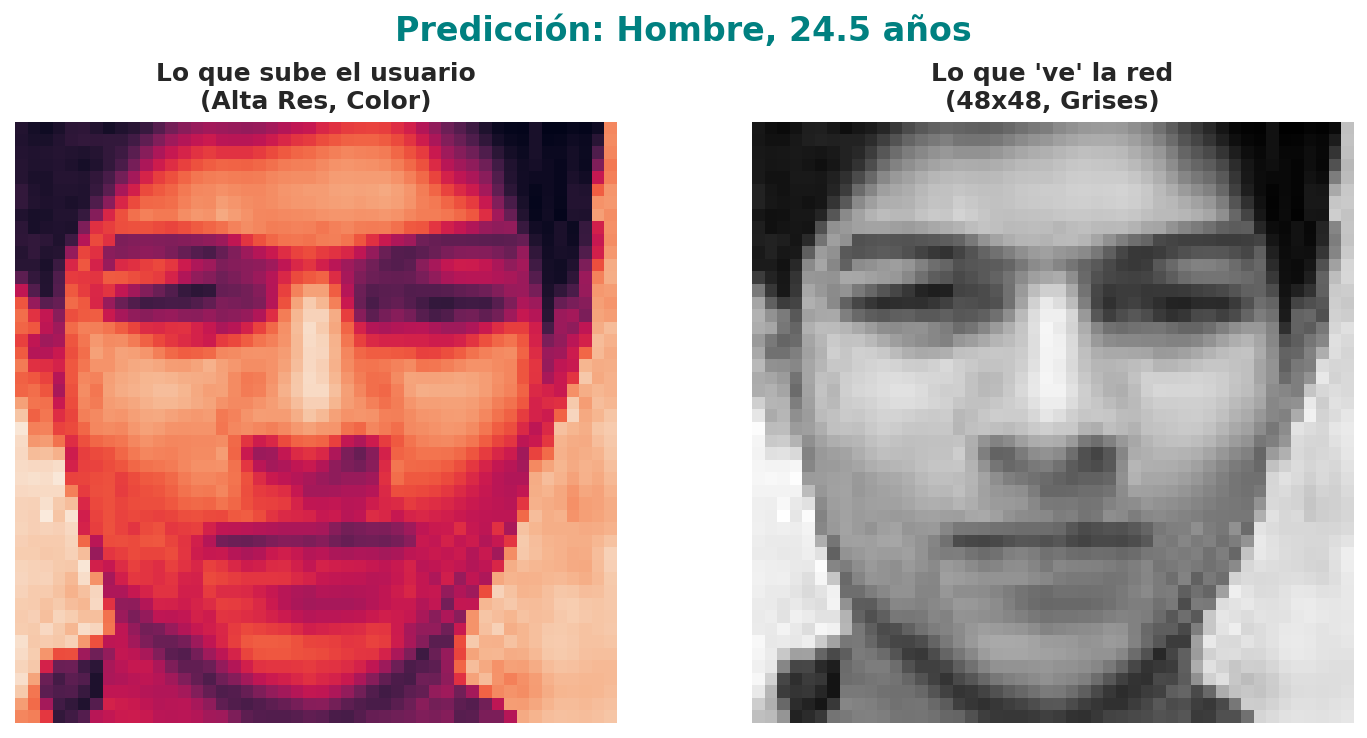

In [88]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

def procesar_e_inferir_imagen(ruta_imagen, modelo, escalador_edad):
    """
    Carga una imagen, la preprocesa, realiza la inferencia y compara visualmente
    la imagen original con el tensor que ingresa a la red.

    Args:
        ruta_imagen (str): Ruta al archivo de imagen.
        modelo (keras.Model): El modelo multi-tarea entrenado.
        escalador_edad (MinMaxScaler): El escalador usado para normalizar la edad.
    """
    try:
        # 1. Carga de la imagen original (Alta resolución, Color)
        img_original = Image.open(ruta_imagen)

        # 2. Preprocesamiento estricto (Debe coincidir con el entrenamiento)
        # Convertir a escala de grises ('L') y redimensionar a 48x48
        img_procesada = img_original.convert('L').resize((48, 48))

        # Convertir a array de numpy y normalizar al rango [0, 1]
        img_array = np.array(img_procesada, dtype='float32') / 255.0

        # Añadir dimensiones de batch y canal: El modelo espera (1, 48, 48, 1)
        input_tensor = img_array.reshape(1, 48, 48, 1)

        # 3. Inferencia (Forward Pass)
        pred_genero_prob, pred_edad_escalada = modelo.predict(input_tensor, verbose=0)

        # 4. Post-procesamiento (Traducción a reglas de negocio)
        clase_genero = (pred_genero_prob[0][0] > 0.5).astype(int)
        genero_str = "Mujer" if clase_genero == 1 else "Hombre"
        edad_real = escalador_edad.inverse_transform(pred_edad_escalada).flatten()[0]

        # 5. Visualización Comparativa
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Imagen Original
        axes[0].imshow(img_original)
        axes[0].axis('off')
        axes[0].set_title("Lo que sube el usuario\n(Alta Res, Color)", fontsize=12)

        # Imagen Procesada (Lo que ve la red)
        axes[1].imshow(img_procesada, cmap='gray')
        axes[1].axis('off')
        axes[1].set_title(f"Lo que 've' la red\n(48x48, Grises)", fontsize=12)

        plt.suptitle(f"Predicción: {genero_str}, {edad_real:.1f} años", fontsize=16, fontweight='bold', color='teal')
        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"Error: No se encontró la imagen en la ruta: {ruta_imagen}")
    except Exception as e:
        print(f"Ocurrió un error durante el procesamiento: {e}")

# --- Simulación de Inferencia en Producción ---

# Para demostrarlo, tomamos una imagen de nuestro Test Set,
# la guardamos en el disco duro como un archivo .jpg real,
# y la pasamos por nuestro pipeline.

ruta_prueba = "rostro_prueba.jpg"

# Seleccionamos una imagen al azar del Test Set y la guardamos
idx_azar = 42
imagen_test_cruda = (X_test[idx_azar].reshape(48, 48) * 255).astype(np.uint8)
Image.fromarray(imagen_test_cruda, mode='L').save(ruta_prueba)

print("--- Ejecutando Pipeline de Inferencia ---")
procesar_e_inferir_imagen(ruta_prueba, modelo_multitask, scaler_age)

# Limpieza del archivo temporal
if os.path.exists(ruta_prueba):
    os.remove(ruta_prueba)

Prueba con imagen subida directamente al sistema de archivos de Colab:

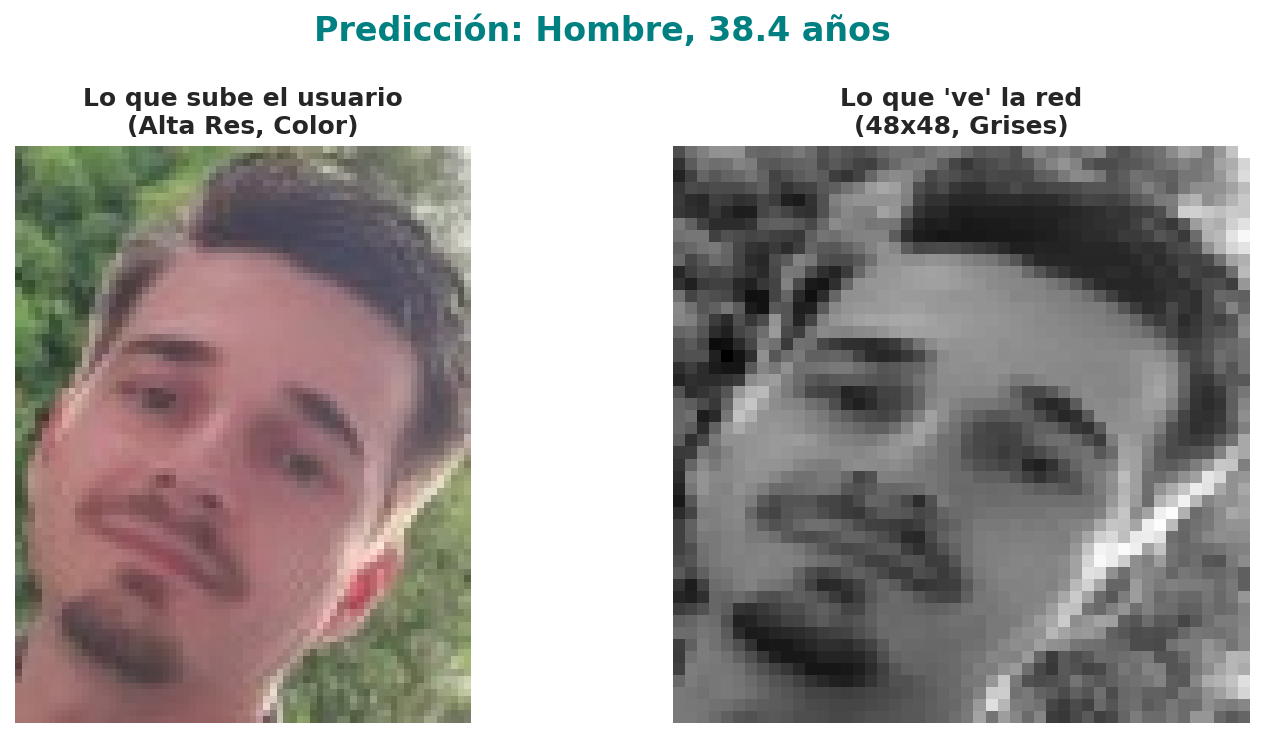

In [89]:
# Imagen desde el sistema de archivos
imagen_real = "foto_28anios.jpg"

procesar_e_inferir_imagen(imagen_real, modelo_multitask, scaler_age)

Prueba con imagen desde un enlace:

1421/1421 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
--- Ejecutando Pipeline de Inferencia ---


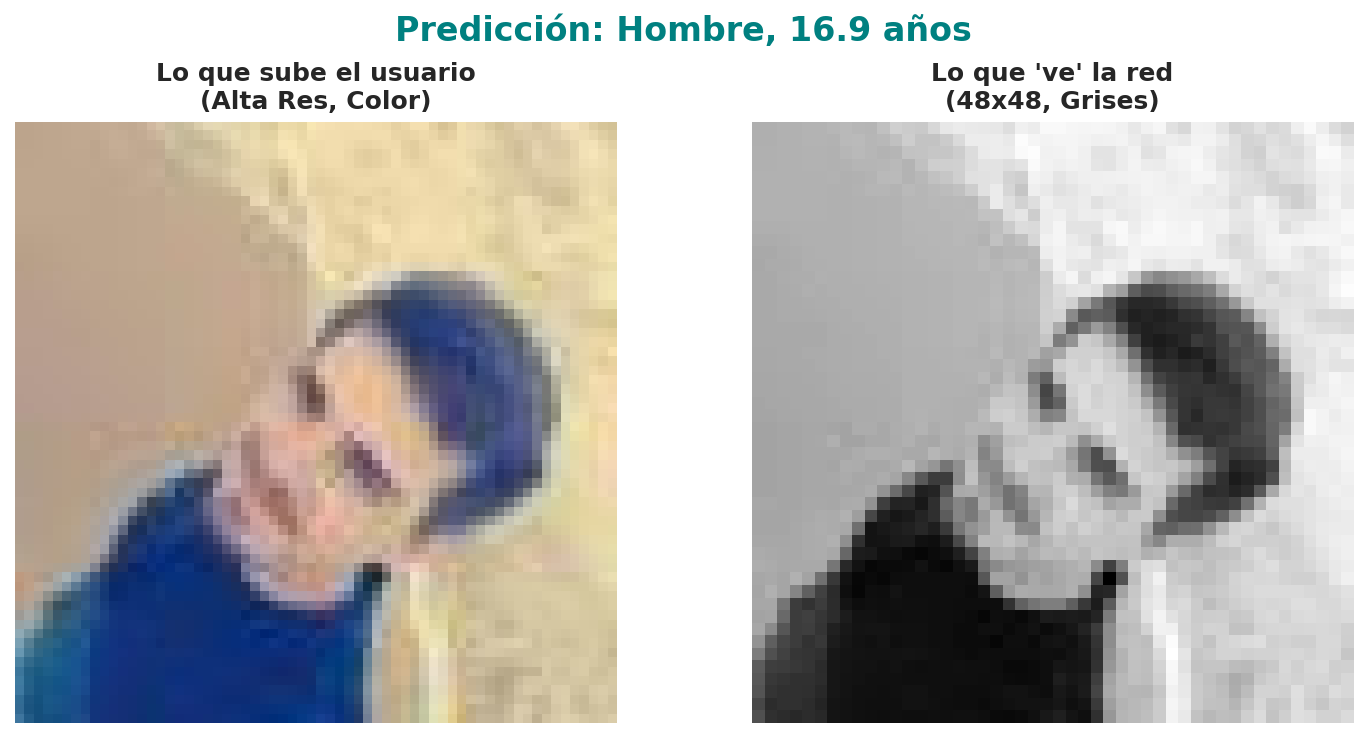

In [91]:
url_prueba = "https://avatars.githubusercontent.com/u/71282781?v=4&size=64"

# Usamos keras para descargar la imagen rápidamente
ruta_descargada = keras.utils.get_file(ruta_prueba, origin=url_prueba)

print("--- Ejecutando Pipeline de Inferencia ---")
procesar_e_inferir_imagen(ruta_descargada, modelo_multitask, scaler_age)

### Criterio de Ingeniería: Sesgos y Datos Fuera de Distribución (OOD)

Observar la diferencia entre las imagenes originales y la imagen de 48x48 en escala de grises. Los casos probados tienen una resolución cercana a la esperada, y, así y todo, sufren modificaciones evidentes.
Esta pérdida de información nos obliga a plantearnos problemas críticos antes de lanzar este modelo a producción:

1. **El Problema del Encuadre (Cropping):** Nuestro modelo fue entrenado con un dataset donde **el rostro ocupa el 100% del cuadro**. Si un usuario sube una foto de cuerpo entero, la función `resize(48, 48)` aplastará todo el cuerpo en la imagen. El rostro quedará reducido a 3x3 píxeles. La red no dará un error; simplemente emitirá una predicción basura.
   * **Solución de Industria:** El pipeline real necesita un paso previo. Antes de nuestra CNN, debe correr un modelo de **Detección Facial** (como *Haar Cascades* o *MTCNN*) que encuentre la caja delimitadora (*Bounding Box*) del rostro, lo recorte, y *solo ese recorte* se envíe a nuestra red. *Probar el funcionamiento realizando este paso manualmente, es decir; con imágenes de rostros encuadrados.*
2. **Pérdida de Textura (Edad):** Al reducir a 48x48 y quitar el color, se pierden detalles finos como arrugas sutiles, canas o tonos de piel que los humanos usamos para estimar la edad. Esto explica por qué el MAE de la edad tiene un límite físico que no podremos superar con esta resolución.
3. **Sesgos de Iluminación y Fondo:** Si el dataset original (`age_gender.csv`) fue recolectado con buena iluminación frontal y fondos neutros, el modelo fallará si procesa un frame de una cámara de seguridad oscura con luces de neón de fondo. A esto se le llama **Data Shift** (Desplazamiento de Datos).
   * **Solución de Industria:** Aplicar **Data Augmentation** agresivo durante el entrenamiento (cambios de brillo, contraste, inyección de ruido) para forzar a la red a ignorar el fondo y centrarse en la morfología facial.

## 8. Restricciones de Hardware: Latencia y Viabilidad



Nuestro cliente requiere que el modelo corra en hardware embebido (Edge Computing). Evaluamos si nuestra arquitectura cumple.



In [13]:
# 1. Tamaño del Modelo
total_params = modelo_multitask.count_params()
print(f"Total de Parámetros: {total_params:,}")

# 2. Prueba de Latencia (Simulando un stream de video a 30 FPS)
# Creamos un batch de 32 rostros (simulando las caras detectadas en 1 segundo de video)
batch_prueba = np.random.rand(32, 48, 48, 1).astype('float32')

# Calentamiento de la GPU/CPU (la primera inferencia siempre es más lenta por inicialización)
_ = modelo_multitask.predict(batch_prueba, verbose=0)

# Medición real
inicio = time.time()
_ = modelo_multitask.predict(batch_prueba, verbose=0)
fin = time.time()

latencia_ms = (fin - inicio) * 1000
print(f"Latencia para procesar 32 rostros: {latencia_ms:.2f} ms")

Total de Parámetros: 110,210
Latencia para procesar 32 rostros: 68.07 ms


**Veredicto de Despliegue:**
Nuestra CNN tiene menos de **`200.000` parámetros**. Un modelo denso (MLP) equivalente tendría millones. Gracias al uso de `GlobalAveragePooling2D` y la arquitectura Multi-Task (que extrae características una sola vez para ambas tareas), la latencia es de apenas unos pocos milisegundos. Es **absolutamente viable** desplegar este modelo en una Raspberry Pi o un Jetson Nano para operar en tiempo real.

## 7. Ética, Sesgos y Privacidad por Diseño


Como ingenieros, nuestra responsabilidad no termina en la métrica de *Loss*. Un modelo matemáticamente correcto puede ser socialmente desastroso.

1. **Sesgos del Dataset:** Observar el gráfico de dispersión de la edad. El modelo tiende a predecir edades cercanas a los 30-40 años para personas muy mayores (80+). Esto ocurre porque el dataset está fuertemente desbalanceado hacia adultos jóvenes. Si desplegamos esto, el sistema tendrá un rendimiento discriminatorio, fallando sistemáticamente en ancianos y minorías étnicas subrepresentadas. Pero, están también las limitaciones ya discutidas sobre la resolución de las imágenes y color, hay features que no se van a poder obtener en el estado actual (pérdida de información), tengamos la arquitectura que tengamos.
2. **Privacidad por Diseño (Privacy by Design):** Al ejecutar este modelo liviano directamente en la memoria RAM de la cámara (*Edge Computing*), el sistema toma el frame de video, extrae el rostro, genera el vector `[Edad: 32, Genero: M]` y **destruye la imagen inmediatamente**. Nunca se guarda un píxel en el disco duro ni se envía a la nube. Esto garantiza el cumplimiento de leyes de privacidad como GDPR, protegiendo la identidad de los transeúntes.

## Conexiones y Próximos Pasos


Construimos una arquitectura convolucional profesional desde cero. Sin embargo, entrenar CNNs requiere decenas de miles de imágenes. ¿Qué pasa si nuestro cliente nos pide detectar si una persona lleva puesta una mascarilla médica (barbijo), pero solo tenemos 500 fotos de ejemplo? Pronto resolvemos este tipo de situaciones...

- ➡️ **Siguiente:** En el notebook [NLP y Secuencias: Embeddings, LSTM y el Manejo del Tiempo](10_nlp_embeddings_y_secuencias.ipynb), aprendemos a procesar secuencias temporales con capas especializas. Incluyendo frases y/o texto para analizar sentimientos.
- 🔄 **Relacionado:** En el notebook [Transfer Learning y Fine-Tuning](12_transfer_learning_y_fine_tuning.ipynb), aprendemos a descargar modelos grande (como ResNet o MobileNet) pre-entrenados con millones de imágenes, y les "injertaremos" nuestras propias cabezas para resolver problemas complejos con muy pocos datos.

## Referencias


### Artículos Fundacionales

1. **LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998)**. *Gradient-Based Learning Applied to Document Recognition*. Proceedings of the IEEE.  
   (El paper clásico que popularizó las CNNs modernas).

2. **Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012)**. *ImageNet Classification with Deep Convolutional Neural Networks* (AlexNet). NeurIPS.  
   [[PDF]](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)  
   (El paper que inició la revolución del Deep Learning en visión).

3. **Lin, M., Chen, Q., & Yan, S. (2013)**. *Network In Network*. arXiv.  
   [[arXiv]](https://arxiv.org/abs/1312.4400) (Introdujo Global Average Pooling).

4. **Caruana, R. (1997)**. *Multitask Learning*. Machine Learning Journal. (Fundamentos teóricos del Multi-Task Learning).

### Recursos Prácticos

- **Chollet, F. (2021)**. *Deep Learning with Python, Second Edition* (Capítulos sobre CNNs). Manning.
- **Simonyan, K., & Zisserman, A. (2014)**. *Very Deep Convolutional Networks for Large-Scale Image Recognition* (VGG). arXiv. [[arXiv]](https://arxiv.org/abs/1409.1556)
- Documentación oficial:  
  [Keras CNN Guide](https://keras.io/examples/vision/image_classification_from_scratch/)


---


## Entorno de Ejecución


In [31]:
from utils.environment import environment_table
environment_table(include_all=True)

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
Cython,3.0.12
IPython,7.34.0
OpenSSL,24.2.1
PIL,11.3.0
anywidget,0.9.21
argparse,1.1
astunparse,1.6.3
attr,26.1.0
